In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("future.no_silent_downcasting", True)

### Exploratory Data Analysis

**Visualizing Distributions**

In [ ]:
oscars_summary = pd.read_csv("oscars_summary.csv")
acting_summary = pd.read_csv("acting_summary.csv")
gender_age = pd.read_csv("gender_age.csv")
# gender_rt = pd.read_csv("gender_rt.csv")

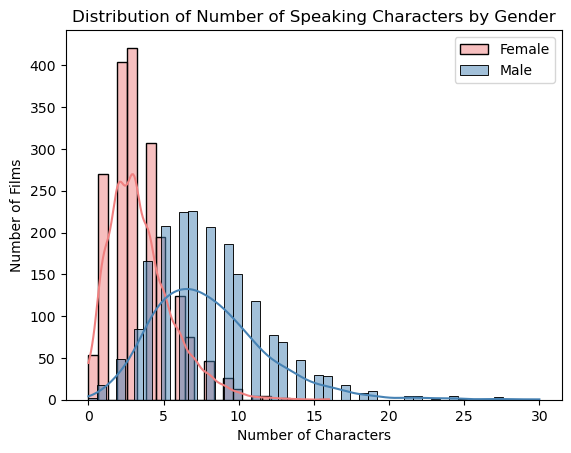

In [4]:
sns.histplot(
    data=oscars_summary, 
    x="num_characters_f", 
    color="lightcoral", 
    label="Female", 
    bins=25,
    kde=True
)
sns.histplot(
    data=oscars_summary, 
    x="num_characters_m", 
    color="steelblue", 
    label="Male", 
    bins=50,
    kde=True)

plt.title("Distribution of Number of Speaking Characters by Gender")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Films")
plt.legend() 
plt.show()

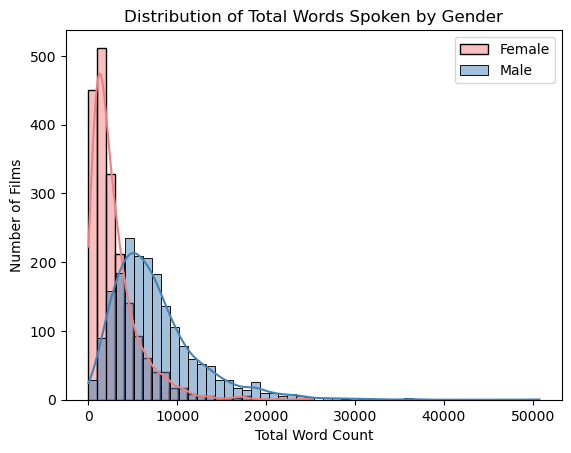

In [5]:
sns.histplot(
    data=oscars_summary, 
    x="total_words_f", 
    color="lightcoral", 
    label="Female", 
    bins=25,
    kde=True
)
sns.histplot(
    data=oscars_summary, 
    x="total_words_m", 
    color="steelblue", 
    label="Male", 
    bins=50,
    kde=True)

plt.title("Distribution of Total Words Spoken by Gender")
plt.xlabel("Total Word Count")
plt.ylabel("Number of Films")
plt.legend() 
plt.show()

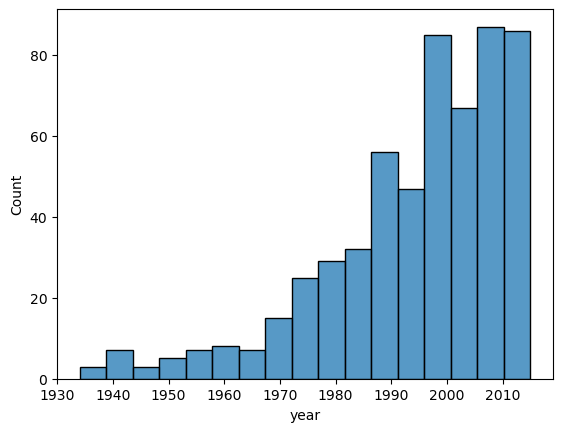

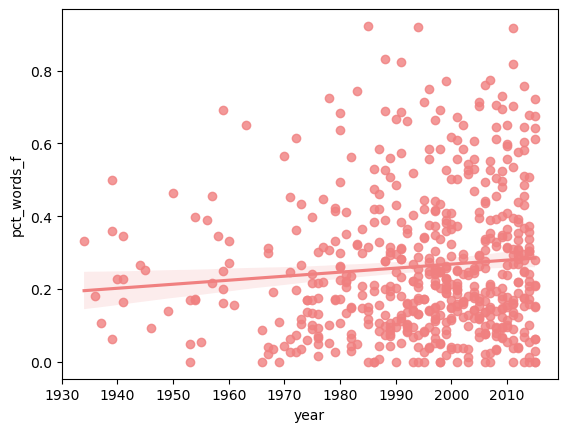

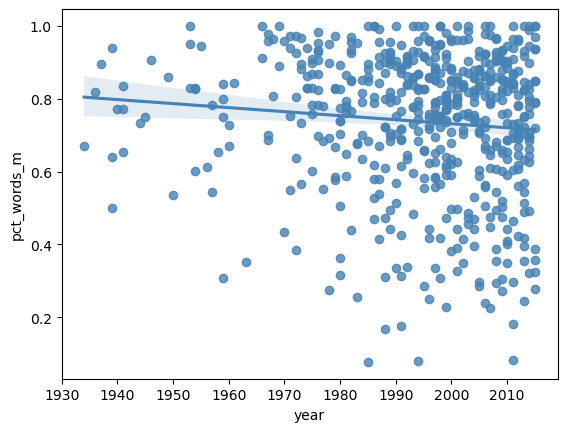

In [4]:
noms = oscars_summary[oscars_summary["total_nominations"] > 0]

sns.histplot(
    data=noms, 
    x="year", 
)
plt.show()

sns.regplot(
    data=noms, 
    x="year", 
    y="pct_words_f",
    color="lightcoral",
)
plt.show()

sns.regplot(
    data=noms, 
    x="year", 
    y="pct_words_m",
    color="steelblue",
)
plt.show()

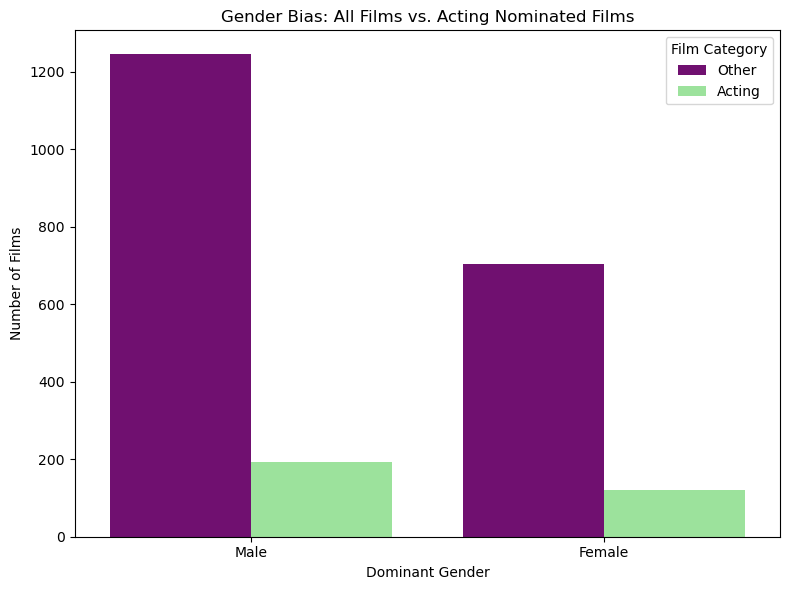

In [ ]:
combined = pd.concat([oscars_summary, acting_summary], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.countplot(
    data=combined,
    x="dominant_gender",
    hue="df_type",
    order=["m", "f"],
    palette={"Other": "purple", "Acting": "lightgreen"}
)

plt.title("Gender Bias: All Films vs. Acting Nominated Films")
plt.xlabel("Dominant Gender")
plt.ylabel("Number of Films")
plt.xticks([0, 1], ["Male", "Female"])
plt.legend(title="Film Category")
plt.tight_layout()
plt.show()

In [ ]:
# plt.figure(figsize=(10, 6))
# sns.boxplot(
#     data=gender_rt,
#     x="dominant_gender",
#     y="tomatometer_rating",
#     palette={"m": "steelblue", "f": "lightcoral"},
#     order=["m", "f"],
#     hue="dominant_gender"
# )

# plt.title("Distribution of Rotten Tomatoes Ratings by Gender Bias")
# plt.xlabel("Dominant Gender")
# plt.xticks([0, 1], ["Male", "Female"])
# plt.ylabel("Tomatometer Rating")
# plt.tight_layout()
# plt.show()

# ct_rt = pd.crosstab(gender_rt["dominant_gender"], gender_rt["tomatometer_status"])
# ct_rt_scaled = ct_rt.div(ct_rt.sum(axis=1), axis=0)

# sns.heatmap(
#     ct_rt_scaled,
#     annot=True,
#     cmap="Reds",
# )

# plt.title("Heatmap of Gender Bias vs Tomatometer Status")
# plt.xlabel("Tomatometer Status")
# plt.ylabel("Gender Dominance")
# plt.yticks(ticks=[0.5, 1.5], labels=["Female", "Male"])
# plt.show()

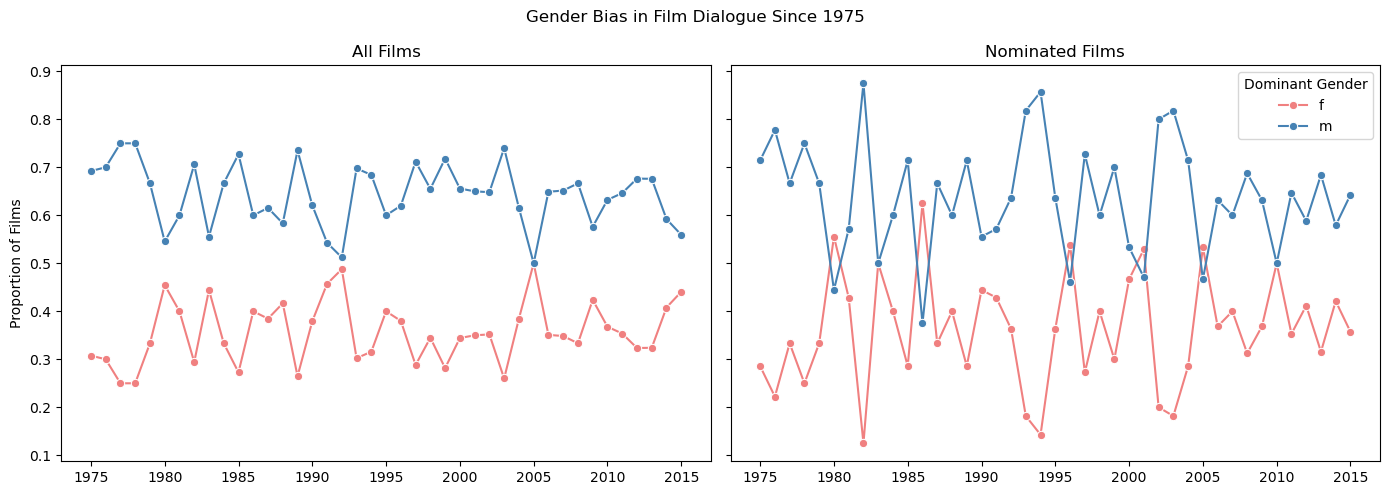

In [41]:
# group all films
all_plot = (
    oscars_summary.groupby(["year", "dominant_gender"])
    .size()
    .reset_index(name="count_all")
)

# group only nominated films
nom_plot = (
    oscars_summary[oscars_summary["nominated"] == True]
    .groupby(["year", "dominant_gender"])
    .size()
    .reset_index(name="count_nominated")
)

# merge the two summaries
merge_plot = pd.merge(
    all_plot,
    nom_plot,
    on=["year", "dominant_gender"],
    how="left"
)

# replace NaN (years without nominated films for that gender)
merge_plot["count_nominated"] = merge_plot["count_nominated"].fillna(0)

# compute percentages
merge_plot["pct_all"] = merge_plot.groupby("year")["count_all"].transform(
    lambda x: x / x.sum()
)

merge_plot["pct_nominated"] = merge_plot.groupby("year")["count_nominated"].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0
)

# drop years before 1975
merge_plot = merge_plot[merge_plot["year"] >= 1975]

# Set up subplot grid
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# ---- Left plot: All films ----
sns.lineplot(
    data=merge_plot,
    x="year",
    y="pct_all",
    hue="dominant_gender",
    marker="o",
    ax=axes[0],
    palette={"m": "steelblue", "f": "lightcoral"}
)
axes[0].set_title("All Films")
axes[0].set_xlabel("")
axes[0].set_ylabel("Proportion of Films")

# ---- Right plot: Nominated films ----
sns.lineplot(
    data=merge_plot,
    x="year",
    y="pct_nominated",
    hue="dominant_gender",
    marker="o",
    ax=axes[1],
    palette={"m": "steelblue", "f": "lightcoral"}
)
axes[1].set_title("Nominated Films")
axes[1].set_xlabel("")
axes[1].set_ylabel("")  # share y-axis

# Make legend appear once instead of twice
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend().remove()
axes[1].legend(handles, labels, title="Dominant Gender")

plt.suptitle("Gender Bias in Film Dialogue Since 1975")
plt.tight_layout()
plt.show()

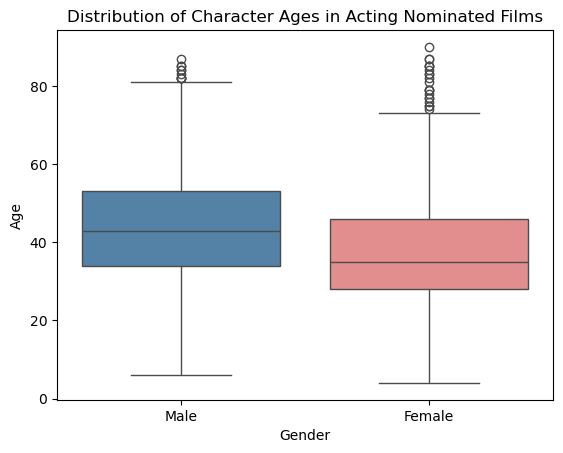

In [7]:
sns.boxplot(
    data=gender_age, 
    x="gender", 
    y="age",
    palette={"m": "steelblue", "f": "lightcoral"},
    order=["m", "f"],
    hue="gender"
)

plt.title("Distribution of Character Ages in Acting Nominated Films")
plt.xlabel("Gender")
plt.ylabel("Age")
plt.xticks([0, 1], ["Male", "Female"])
plt.show()

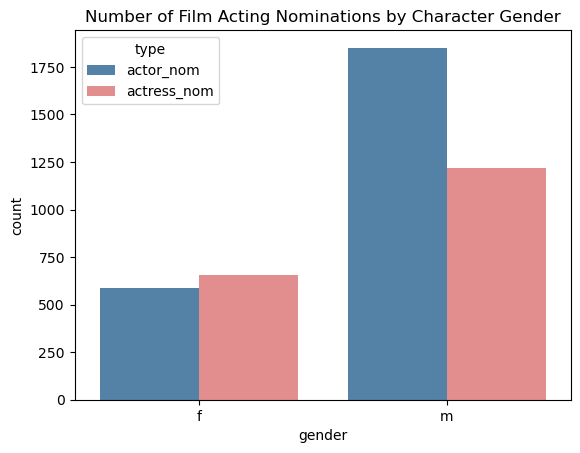

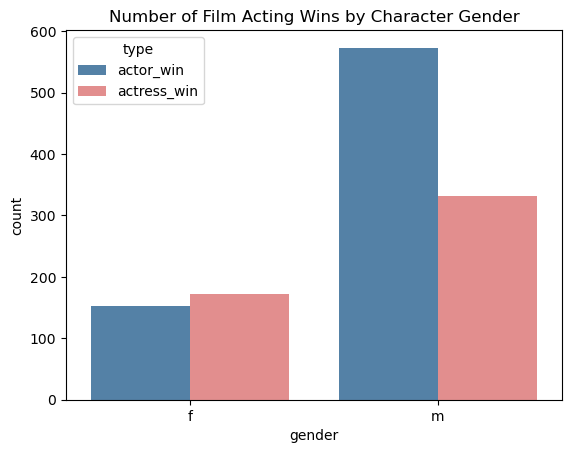

In [10]:
nom_counts = gender_age.groupby("gender")[["actor_nom","actress_nom"]].sum().reset_index()
nom_counts = nom_counts.melt(id_vars="gender", var_name="type", value_name="count")

sns.barplot(x="gender", y="count", hue="type", palette={"actor_nom": "steelblue", "actress_nom": "lightcoral"}, data=nom_counts)
plt.title("Number of Film Acting Nominations by Character Gender")
plt.show()

win_counts = gender_age.groupby("gender")[["actor_win","actress_win"]].sum().reset_index()
win_counts = win_counts.melt(id_vars="gender", var_name="type", value_name="count")

sns.barplot(x="gender", y="count", hue="type", palette={"actor_win": "steelblue", "actress_win": "lightcoral"}, data=win_counts)
plt.title("Number of Film Acting Wins by Character Gender")
plt.show()